# Run experiment

## Loading in the dataset

In [149]:
from utils_3 import PairwiseData, Population
from datasets import load_dataset

ds = load_dataset("lmarena-ai/arena-human-preference-140k")
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

100%|██████████| 30/30 [00:01<00:00, 27.95it/s]


In [150]:
len(pw.winners)

37454

## Sampling pairs

In [151]:
import numpy as np

In [152]:
NUM_SAMPLES = 30_000
BETA = 1.0

In [153]:
def expit(x):
    x = np.asarray(x)
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x)),
    )

In [154]:
model_A = 0
model_B = 1

population.population_utilities[..., model_A].shape

(30,)

Assuming independent distribution for now.

In [155]:
candidates = np.arange(pw.M)
voters = np.arange(pw.N)

In [156]:
from tqdm import tqdm

In [157]:
winners = []
losers = []

for _ in tqdm(range(NUM_SAMPLES)):
    model_A = np.random.choice(candidates, p=pw.candidate_distr)
    model_B = np.random.choice(candidates, p=pw.candidate_distr)

    p = (expit(BETA * (population.population_utilities[..., model_A] - population.population_utilities[..., model_B])) * population.voter_distr).sum()

    if np.random.rand() < p:
        winners.append(model_A)
        losers.append(model_B)

    else:
        winners.append(model_B)
        losers.append(model_A)

winners = np.asarray(winners)
losers = np.asarray(losers)

100%|██████████| 30000/30000 [00:01<00:00, 18405.14it/s]


In [158]:
winners

array([ 5, 27,  0, ..., 19,  7,  3], shape=(30000,))

In [159]:
def borda_from_pairwise(winners, losers, n_items=None):
    winners = np.asarray(winners)
    losers = np.asarray(losers)

    if n_items is None:
        n_items = max(winners.max(), losers.max()) + 1

    scores = np.zeros(n_items, dtype=int)

    for w in winners:
        scores[w] += 1

    denom = np.zeros(n_items, dtype=int)
    for l in losers:
        denom[l] += 1

    denom = denom + scores + 1e-6
    scores = scores / denom

    ranking = np.argsort(-scores)  # descending
    return scores, ranking

In [160]:
scores, ranking = borda_from_pairwise(winners=winners, losers=losers, n_items=pw.M)
print(ranking)

true_ranking = np.argsort(-population.avg_utilities)
print(true_ranking)

[ 1 20  5  7 14 23  2  3  4 17 16 21 27  0  9 25 18 22 26 24 29 13 12  6
 11  8 28 10 15 19]
[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]


In [161]:
from utils_3 import leaderboard_dist

In [162]:
distortion = leaderboard_dist(ranking=ranking, true_ranking=true_ranking, avg_utils=population.avg_utilities)
print(distortion)

(np.float64(1.0099553753099328), np.int64(1))


## Actually sampling voters as well

In [163]:
winners = []
losers = []

for _ in tqdm(range(NUM_SAMPLES)):
    model_A = np.random.choice(candidates, p=pw.candidate_distr)
    model_B = np.random.choice(candidates, p=pw.candidate_distr)
    voter = np.random.choice(voters, p=population.voter_distr)

    p = expit(BETA * (population.population_utilities[voter, model_A] - population.population_utilities[voter, model_B]))

    if np.random.rand() < p:
        winners.append(model_A)
        losers.append(model_B)

    else:
        winners.append(model_B)
        losers.append(model_A)

winners = np.asarray(winners)
losers = np.asarray(losers)

100%|██████████| 30000/30000 [00:01<00:00, 15276.39it/s]


In [164]:
scores, ranking = borda_from_pairwise(winners=winners, losers=losers, n_items=pw.M)
print(ranking)

true_ranking = np.argsort(-population.avg_utilities)
print(true_ranking)

[ 1  5  7 20 14 23  2  3 16 21 17  4 18  9  0 22 27 25 26 29 24 13  6 12
 28 11  8 19 10 15]
[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]


In [165]:
distortion = leaderboard_dist(ranking=ranking, true_ranking=true_ranking, avg_utils=population.avg_utilities)
print(distortion)

(np.float64(1.0092163880218774), np.int64(15))


## Plotting ten trials

In [166]:
from scipy.special import expit
import matplotlib.pyplot as plt

In [167]:
from scipy.optimize import linprog

def win_matrix_from_pairwise(w_arr, l_arr, n_items):
    ij_wins = np.zeros((n_items, n_items))
    np.add.at(ij_wins, (w_arr, l_arr), 1)
    total = ij_wins + ij_wins.T
    # with np.errstate(invalid='ignore', divide='ignore'):
    #     P = np.where(total > 0, ij_wins / total, 0.5)
    # np.fill_diagonal(P, 0.5)
    assert not bool((total == 0.0).any()), 'cant divide by zero!'
    P = ij_wins / total
    return P

def ij_from_pairwise(w_arr, l_arr, n_items):
    ij_wins = np.zeros((n_items, n_items))
    np.add.at(ij_wins, (w_arr, l_arr), 1.0)
    return ij_wins

def _solve_maximal_lottery(margins, tie_tol=1e-12):
    C = margins.shape[0]
    result = linprog(
        c=np.zeros(C),
        A_ub=-margins.T,
        b_ub=np.zeros(C),
        A_eq=np.ones((1, C)),
        b_eq=np.array([1.0]),
        bounds=[(0.0, 1.0)] * C,
        method='highs',
    )
    lottery = np.maximum(result.x if result.success else np.ones(C) / C, 0)
    lottery[lottery < tie_tol] = 0.0
    s = lottery.sum()
    return lottery / s if s > 0 else np.ones(C) / C

def borda_ranking(ij_wins, with_scores=False):
    num = ij_wins.sum(axis=1)
    denom = ij_wins.sum(axis=1) + ij_wins.sum(axis=0)
    scores = num / denom
    if with_scores:
        return np.argsort(-scores), scores
    else:
        return np.argsort(-scores)

def borda_peeling_ranking(ij_wins):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        ij_remaining = ij_wins[np.ix_(rem, rem)]
        _, scores = borda_ranking(ij_remaining, with_scores=True)
        w = int(np.argmax(scores))
        ranking.append(remaining[w])
        remaining.pop(w)
    return np.array(ranking)

def copeland_ranking(ij_wins, tol=1e-9):
    m = (ij_wins - ij_wins.T) / (ij_wins + ij_wins.T)
    return np.argsort(-((m > tol).sum(axis=1) - (m < -tol).sum(axis=1)))

def copeland_peeling_ranking(ij_wins, tol=1e-9):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        ij_remaining = ij_wins[np.ix_(rem, rem)]; m = (ij_remaining - ij_remaining.T) / (ij_remaining + ij_remaining.T)
        scores = (m > tol).sum(axis=1) - (m < -tol).sum(axis=1)
        w = int(np.argmax(scores))
        ranking.append(remaining[w]); remaining.pop(w)
    return np.array(ranking)

def ml_argmax_ranking(ij_wins, tol=1e-12):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        sub = ij_wins[np.ix_(rem, rem)]
        with np.errstate(invalid='ignore', divide='ignore'):
            margins = np.where(sub + sub.T > 0, (sub - sub.T) / (sub + sub.T), 0.0)
        lot = _solve_maximal_lottery(margins, tol)
        w = int(np.argmax(lot))
        ranking.append(remaining[w]); remaining.pop(w)
    return np.array(ranking)

def ml_nonzero_ranking(ij_wins, tol=1e-12):
    remaining = list(range(ij_wins.shape[0]))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        sub = ij_wins[np.ix_(rem, rem)]
        with np.errstate(invalid='ignore', divide='ignore'):
            margins = np.where(sub + sub.T > 0, (sub - sub.T) / (sub + sub.T), 0.0)
        lot = _solve_maximal_lottery(margins, tol)
        order = np.argsort(-lot)
        nonzero = order[lot[order] > tol]
        if len(nonzero) == 0:
            nonzero = np.array([int(np.argmax(lot))])
        selected = [remaining[i] for i in nonzero]
        ranking.extend(selected)
        remaining = [c for c in remaining if c not in set(selected)]
    return np.array(ranking)

In [168]:
def ranking_distribution_pruned(candidates, maximal_lottery_fn):
    cache = {}

    def get_lottery(S):
        S = frozenset(S)
        if S not in cache:
            cache[S] = maximal_lottery_fn(list(S))
        return cache[S]

    def recurse(remaining):
        remaining = frozenset(remaining)
        if len(remaining) == 1:
            c = next(iter(remaining))
            return {(c,): 1.0}
        ml = get_lottery(remaining)
        result = {}
        for c, p in ml.items():
            if p == 0:
                continue
            for suffix, q in recurse(remaining - {c}).items():
                result[(c,) + suffix] = p * q
        return result

    return recurse(frozenset(candidates))


def expected_average_utilities(ranking_dist, avg_utilities):
    summed = np.zeros(len(avg_utilities))
    for ranking, p in ranking_dist.items():
        summed += p * avg_utilities[np.asarray(ranking)]
    return summed


def expected_leaderboard_distortion(ranking_dist, true_ranking, avg_utils):
    true_ranking = np.asarray(true_ranking)
    ranking_utils = expected_average_utilities(ranking_dist, avg_utils)
    true_ranking_utils = avg_utils[true_ranking]
    denom_cumsum = np.cumsum(ranking_utils)
    num_cumsum   = np.cumsum(true_ranking_utils)
    return float(np.max(num_cumsum / denom_cumsum))


def make_ml_fn_from_ij_wins(ij_wins):
    def fn(candidates):
        sub = ij_wins[np.ix_(candidates, candidates)]
        with np.errstate(invalid='ignore', divide='ignore'):
            margins = np.where(sub + sub.T > 0, (sub - sub.T) / (sub + sub.T), 0.0)
        lot = _solve_maximal_lottery(margins)
        return {c: float(lot[i]) for i, c in enumerate(candidates)}
    return fn

In [169]:
empirical_distr = np.zeros(len(pw.candidate_distr))

for i in range(len(winners)):
    empirical_distr[winners[i]] += 1
    empirical_distr[losers[i]] += 1

empirical_distr = empirical_distr / empirical_distr.sum()

In [170]:
NUM_ROUNDS = 10
NUM_SAMPLES = 30_000
betas = np.asarray([3.0, 5.0, 10.0, 15.0, 20, 25, 30.0, 35.0, 40.0, 45.0, 50.0]) # 0.01, 0.1, 0.5, 1.0, 2.0, 
true_ranking = np.argsort(-population.avg_utilities)

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_argmax', 'ml_nonzero', 'ml_sampling']
betas_distortions = {m: {float(b): [] for b in betas} for m in methods}

# sample pairs once — only Bernoulli draws vary across rounds
model_As_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=empirical_distr)
model_Bs_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=empirical_distr)

for beta in tqdm(betas, desc='beta'):
    u_diff = population.population_utilities[:, model_As_fixed] - population.population_utilities[:, model_Bs_fixed]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    for _ in range(NUM_ROUNDS):
        mask = np.random.rand(NUM_SAMPLES) < p
        w_arr = np.where(mask, model_As_fixed, model_Bs_fixed)
        l_arr = np.where(mask, model_Bs_fixed, model_As_fixed)

        ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

        for m, fn in [
            ('borda',            borda_ranking),
            ('borda_peeling',    borda_peeling_ranking),
            ('copeland',         copeland_ranking),
            ('copeland_peeling', copeland_peeling_ranking),
            ('ml_argmax',        ml_argmax_ranking),
            ('ml_nonzero',       ml_nonzero_ranking),
        ]:
            dist, _ = leaderboard_dist(fn(ij_wins), true_ranking, population.avg_utilities)
            betas_distortions[m][float(beta)].append(dist)

        ml_fn = make_ml_fn_from_ij_wins(ij_wins)
        ranking_dist = ranking_distribution_pruned(list(range(pw.M)), ml_fn)
        dist = expected_leaderboard_distortion(ranking_dist, true_ranking, population.avg_utilities)
        betas_distortions['ml_sampling'][float(beta)].append(dist)

beta: 100%|██████████| 11/11 [00:44<00:00,  4.02s/it]


In [171]:
beta = 3.0
u_diff = population.population_utilities[:, model_As_fixed] - population.population_utilities[:, model_Bs_fixed]
p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

mask = np.random.rand(NUM_SAMPLES) < p
w_arr = np.where(mask, model_As_fixed, model_Bs_fixed)
l_arr = np.where(mask, model_Bs_fixed, model_As_fixed)

ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

ranking = borda_ranking(ij_wins)
true_ranking = np.argsort(-population.avg_utilities)

print(ranking)
print(true_ranking)

[ 1 20  7  5 14 23  2 16  3 21  4 17  0 18 25  9 27 26 22 24 29 13  6 12
 28  8 11 19 10 15]
[ 1  5  7 20 14 23  2  3 16 21  4 17 27  0 18 25  9 26 22 24 29 13  6 12
 28  8 11 10 19 15]


In [172]:
num = ij_wins.sum(axis=1)

In [173]:
print(num)

[1514. 2415. 1875. 1513. 1415. 1898.  893. 1645.  512.  974.  395.  494.
  641.  675. 1430.  295. 1102. 1013.  845.  333. 1238. 1007.  747. 1184.
  677.  872.  727.  743.  385.  543.]


[2926. 2816. 2731. 2588. 2469. 2532. 2496. 2170. 2075. 2014. 2153. 2005.
 1916. 1862. 1943. 1849. 1876. 1846. 1636. 1807. 1611. 1745. 1706. 1699.
 1653. 1770. 1602. 1540. 1529. 1435.]
1770.0


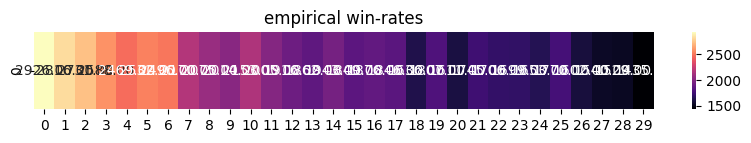

In [174]:
denom = ij_wins.sum(axis=1) + ij_wins.sum(axis=0)
print(denom)
print(denom[25])

plt.figure(figsize=(10, 1))
sns.heatmap(
    denom[None],
    annot=True,
    fmt=".2f",
    cmap="magma"
)
plt.title("empirical win-rates")
plt.show()

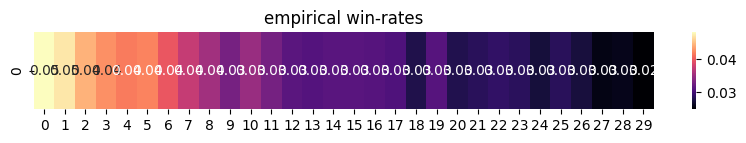

In [175]:
plt.figure(figsize=(10, 1))
sns.heatmap(
    empirical_distr[None],
    annot=True,
    fmt=".2f",
    cmap="magma"
)
plt.title("empirical win-rates")
plt.show()

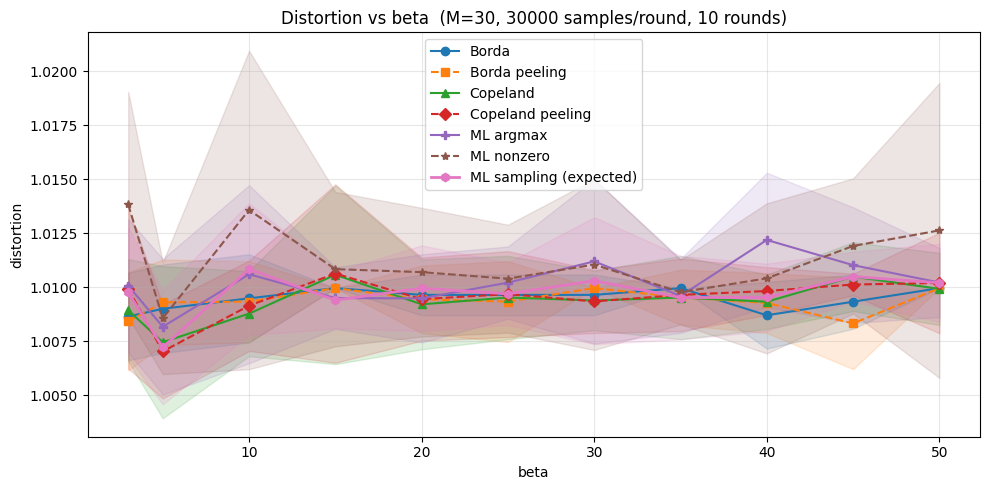

In [176]:
method_style = {
    'borda':            dict(color='C0', marker='o', linestyle='-',  label='Borda'),
    'borda_peeling':    dict(color='C1', marker='s', linestyle='--', label='Borda peeling'),
    'copeland':         dict(color='C2', marker='^', linestyle='-',  label='Copeland'),
    'copeland_peeling': dict(color='C3', marker='D', linestyle='--', label='Copeland peeling'),
    'ml_argmax':        dict(color='C4', marker='P', linestyle='-',  label='ML argmax'),
    'ml_nonzero':       dict(color='C5', marker='*', linestyle='--', label='ML nonzero'),
    'ml_sampling':      dict(color='C6', marker='h', linestyle='-',  label='ML sampling (expected)', linewidth=2),
}

fig, ax = plt.subplots(figsize=(10, 5))
for m, kw in method_style.items():
    means = np.array([np.mean(betas_distortions[m][float(b)]) for b in betas])
    stds  = np.array([np.std( betas_distortions[m][float(b)]) for b in betas])
    ax.plot(betas, means, **kw)
    ax.fill_between(betas, means - stds, means + stds, alpha=0.15, color=kw['color'])

# ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta  (M={pw.M}, {NUM_SAMPLES} samples/round, {NUM_ROUNDS} rounds)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [177]:
(ij_wins) / (ij_wins + ij_wins.T)

array([[0.5       , 0.13868613, 0.25984252, 0.42276423, 0.45098039,
        0.22556391, 0.72435897, 0.2038835 , 0.85057471, 0.55140187,
        0.84545455, 0.85148515, 0.62650602, 0.64356436, 0.23333333,
        0.85416667, 0.39240506, 0.5212766 , 0.40983607, 0.79012346,
        0.18181818, 0.42666667, 0.6627907 , 0.3125    , 0.48051948,
        0.50632911, 0.64285714, 0.5862069 , 0.85507246, 0.63218391],
       [0.86131387, 0.5       , 0.79699248, 0.8943662 , 0.87619048,
        0.71034483, 0.94791667, 0.74528302, 0.94845361, 0.87628866,
        1.        , 0.97727273, 0.96969697, 0.92045455, 0.79120879,
        0.98913043, 0.825     , 0.91397849, 0.88571429, 1.        ,
        0.54117647, 0.81914894, 0.94029851, 0.84146341, 0.96153846,
        0.92424242, 0.82278481, 0.82432432, 0.97560976, 0.96875   ],
       [0.74015748, 0.20300752, 0.5       , 0.61344538, 0.62025316,
        0.38095238, 0.84615385, 0.34939759, 0.91578947, 0.84146341,
        0.96703297, 0.90361446, 0.82142857, 0.

## Fixed weight set

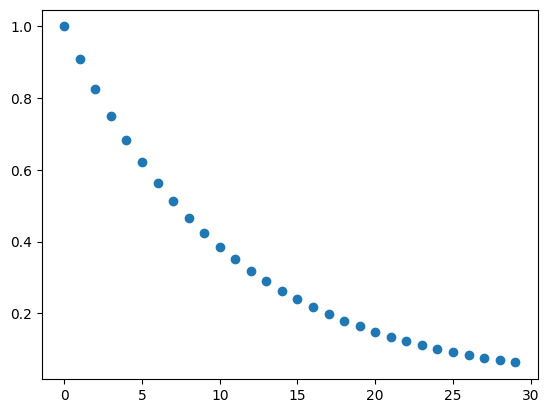

In [178]:
w = 1 / (1.1 ** np.arange(pw.M))
plt.scatter(x=np.arange(len(w)), y=w)

In [179]:
NUM_ROUNDS = 10
betas = np.asarray([3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50]) # 0.01, 0.1, 0.5, 1.0, 2.0, 
true_ranking = np.argsort(-population.avg_utilities)

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_argmax', 'ml_nonzero']
betas_distortions = {m: {float(b): [] for b in betas} for m in methods}

# sample pairs once — only Bernoulli draws vary across rounds
model_As_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=pw.candidate_distr)
model_Bs_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=pw.candidate_distr)

for beta in tqdm(betas, desc='beta'):
    u_diff = population.population_utilities[:, model_As_fixed] - population.population_utilities[:, model_Bs_fixed]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    for _ in range(NUM_ROUNDS):
        mask = np.random.rand(NUM_SAMPLES) < p
        w_arr = np.where(mask, model_As_fixed, model_Bs_fixed)
        l_arr = np.where(mask, model_Bs_fixed, model_As_fixed)

        ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

        for m, fn in [
            ('borda',            borda_ranking),
            ('borda_peeling',    borda_peeling_ranking),
            ('copeland',         copeland_ranking),
            ('copeland_peeling', copeland_peeling_ranking),
            ('ml_argmax',        ml_argmax_ranking),
            ('ml_nonzero',       ml_nonzero_ranking),
        ]:
            dist, _ = leaderboard_dist(fn(ij_wins), true_ranking, population.avg_utilities)
            betas_distortions[m][float(beta)].append(dist)

beta: 100%|██████████| 11/11 [00:09<00:00,  1.22it/s]


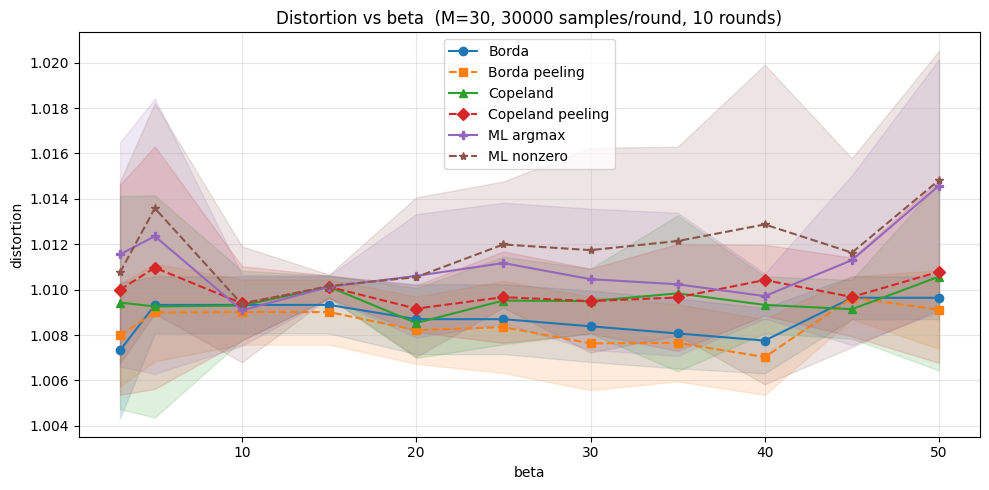

In [180]:
method_style = {
    'borda':            dict(color='C0', marker='o', linestyle='-',  label='Borda'),
    'borda_peeling':    dict(color='C1', marker='s', linestyle='--', label='Borda peeling'),
    'copeland':         dict(color='C2', marker='^', linestyle='-',  label='Copeland'),
    'copeland_peeling': dict(color='C3', marker='D', linestyle='--', label='Copeland peeling'),
    'ml_argmax':        dict(color='C4', marker='P', linestyle='-',  label='ML argmax'),
    'ml_nonzero':       dict(color='C5', marker='*', linestyle='--', label='ML nonzero'),
}

fig, ax = plt.subplots(figsize=(10, 5))
for m, kw in method_style.items():
    means = np.array([np.mean(betas_distortions[m][float(b)]) for b in betas])
    stds  = np.array([np.std( betas_distortions[m][float(b)]) for b in betas])
    ax.plot(betas, means, **kw)
    ax.fill_between(betas, means - stds, means + stds, alpha=0.15, color=kw['color'])

# ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta  (M={pw.M}, {NUM_SAMPLES} samples/round, {NUM_ROUNDS} rounds)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Debugging the population utilities

These are the marginal win-rates.

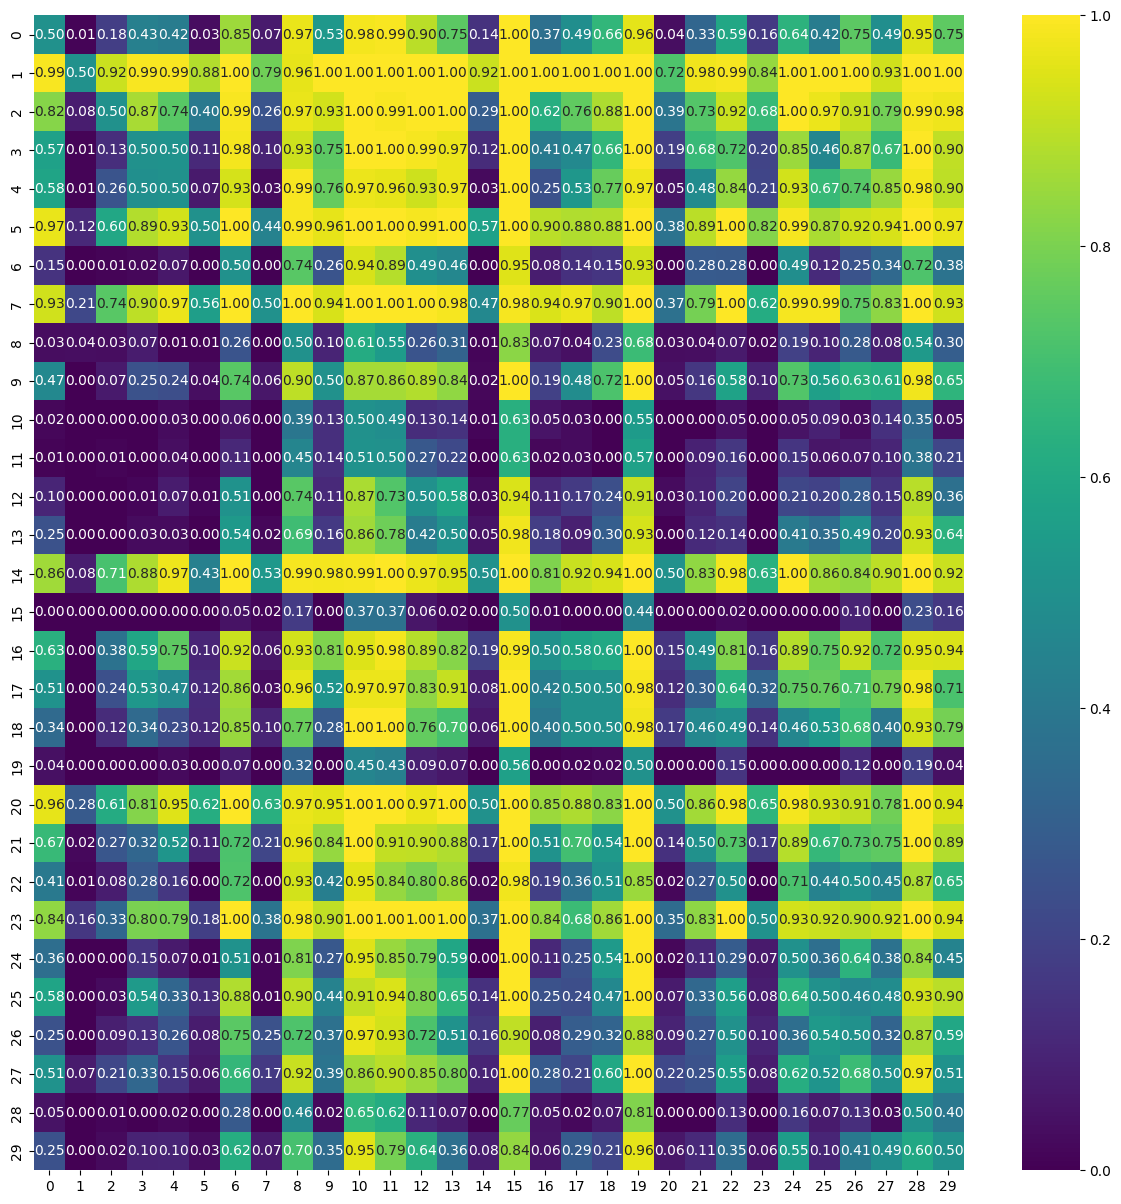

In [181]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
sns.heatmap(
    P,
    annot=True,      # show numbers in cells
    fmt=".2f",       # number format
    cmap="viridis"
)
plt.show()

Plotting the win-rates in general.

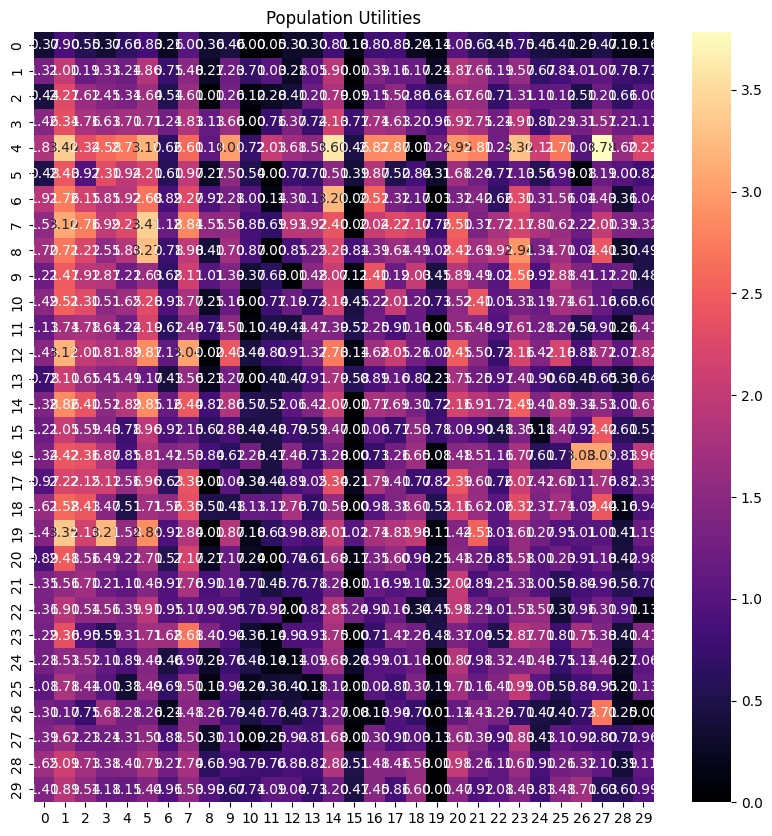

In [182]:
plt.figure(figsize=(10, 10))
sns.heatmap(
    population.population_utilities,
    annot=True,
    fmt=".2f",
    cmap="magma"
)
plt.title("Population Utilities")
plt.show()


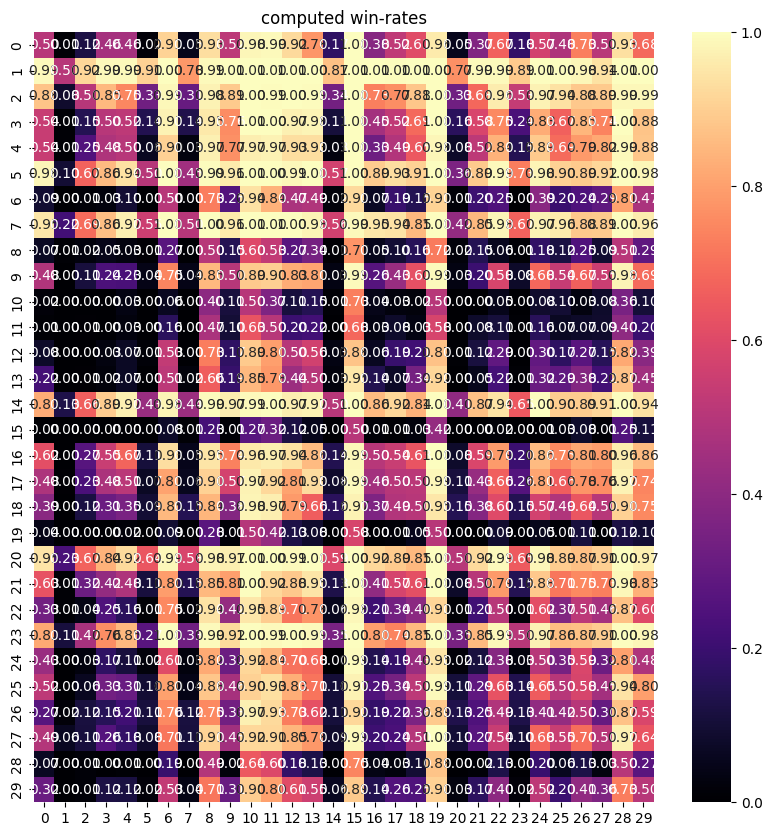

In [183]:
# Computing the win-rate matrix

true_P = np.zeros((pw.M, pw.M), dtype=float)
voter_dist = population.voter_distr

for v, u in enumerate(population.population_utilities):
    diffs = u[:, None] - u[None, :]
    true_P += voter_dist[v] * expit(beta * diffs)

plt.figure(figsize=(10, 10))
sns.heatmap(
    true_P,
    annot=True,
    fmt=".2f",
    cmap="magma"
)
plt.title("computed win-rates")
plt.show()

I guess this does look pretty similar to the sampled one.

In [184]:
NUM_SAMPLES = 1_000_000

model_As = []
model_Bs = []

for _ in tqdm(range(NUM_SAMPLES)):
    model_A = np.random.choice(candidates, p=pw.candidate_distr)
    model_B = np.random.choice(candidates, p=pw.candidate_distr)
    model_As.append(model_A)
    model_Bs.append(model_B)

  0%|          | 0/1000000 [00:00<?, ?it/s]

100%|██████████| 1000000/1000000 [00:31<00:00, 31272.81it/s]


In [185]:
beta = 1.0

In [186]:
u_diff = population.population_utilities[:, model_As] - population.population_utilities[:, model_Bs]
p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)
mask = np.random.rand(NUM_SAMPLES) < p
w_arr = np.where(mask, model_As, model_Bs)
l_arr = np.where(mask, model_Bs, model_As)

False


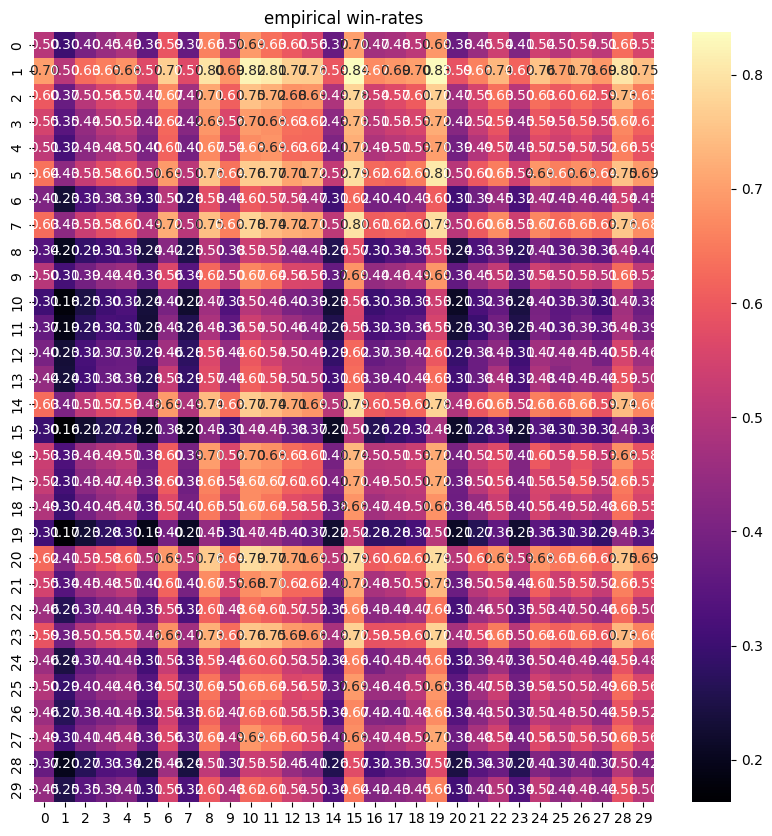

In [187]:
ij_wins = np.zeros((pw.M, pw.M))
np.add.at(ij_wins, (w_arr, l_arr), 1)
total = ij_wins + ij_wins.T

# Assert that the denominator is never zero
print((total == 0.0).any())

P = ij_wins / total

plt.figure(figsize=(10, 10))
sns.heatmap(
    P,
    annot=True,
    fmt=".2f",
    cmap="magma"
)
plt.title("empirical win-rates")
plt.show()

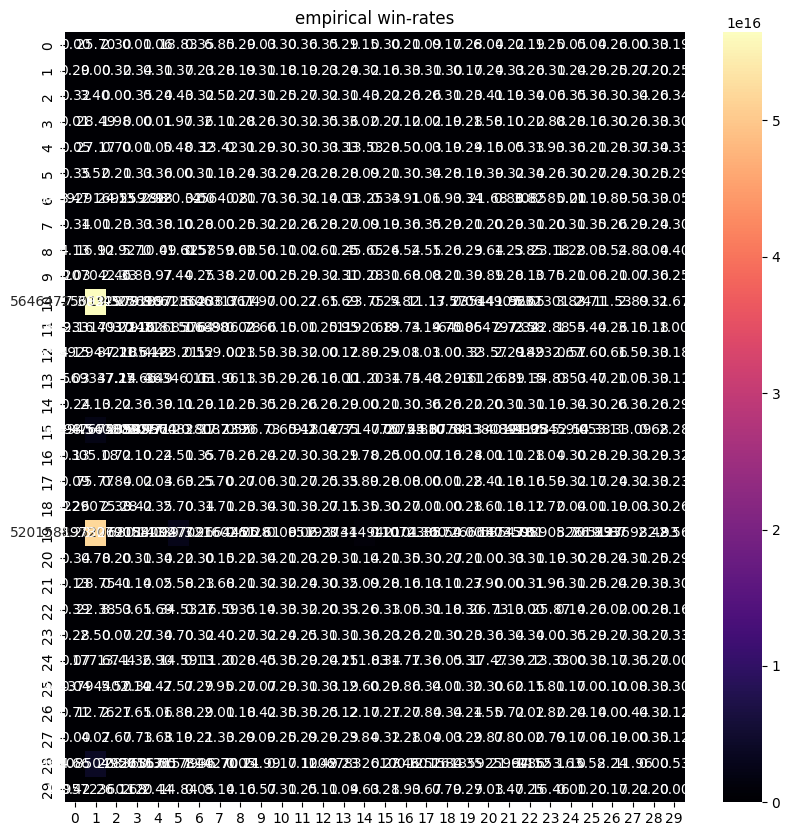

In [188]:
difference = np.abs(true_P - P) / true_P

plt.figure(figsize=(10, 10))
sns.heatmap(
    difference,
    annot=True,
    fmt=".2f",
    cmap="magma"
)
plt.title("empirical win-rates")
plt.show()

Relative error seems pretty small.

Testing Borda computation.

In [189]:
np.argsort(-borda_from_ij_wins(ij_wins))

array([ 1,  5,  7, 20, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       22, 26, 29, 24, 13,  6, 12, 28,  8, 11, 10, 19, 15])

In [190]:
borda_ranking(P)

array([ 1,  5, 20,  7, 14, 23,  2,  3, 16, 21,  4, 17, 27,  0, 18, 25,  9,
       22, 26, 29, 24, 13,  6, 12, 28,  8, 11, 10, 19, 15])

## Trying to debug implementations

In [191]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    ranking = np.asarray(ranking)
    true_ranking = np.asarray(true_ranking)

    ranking_utils = avg_utils[ranking]
    true_ranking_utils = avg_utils[true_ranking]

    # denom_cumsum = np.cumsum(ranking_utils)
    # num_cumsum = np.cumsum(true_ranking_utils)

    # ratio = np.max(num_cumsum / denom_cumsum)
    # k = np.argmax(num_cumsum / denom_cumsum)
    num = true_ranking_utils * w
    denom = ranking_utils * w

    ratio = num.sum() / denom.sum()

    return ratio, None

In [192]:
NUM_ROUNDS = 1
NUM_SAMPLES = 3_000_000
betas = np.asarray([0.01, 0.1, 0.5, 1.0, 2.0, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50, 100]) # 0.01, 0.1, 0.5, 1.0, 2.0, 
true_ranking = np.argsort(-population.avg_utilities)

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling', 'ml_argmax', 'ml_nonzero']
betas_distortions = {m: {float(b): [] for b in betas} for m in methods}

# sample pairs once — only Bernoulli draws vary across rounds
model_As_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=empirical_distr)
model_Bs_fixed = np.random.choice(candidates, size=NUM_SAMPLES, p=empirical_distr)

for beta in tqdm(betas, desc='beta'):
    u_diff = population.population_utilities[:, model_As_fixed] - population.population_utilities[:, model_Bs_fixed]
    p = (expit(beta * u_diff) * population.voter_distr[:, None]).sum(axis=0)

    for _ in range(NUM_ROUNDS):
        mask = np.random.rand(NUM_SAMPLES) < p
        w_arr = np.where(mask, model_As_fixed, model_Bs_fixed)
        l_arr = np.where(mask, model_Bs_fixed, model_As_fixed)

        ij_wins = ij_from_pairwise(w_arr, l_arr, pw.M)

        for m, fn in [
            ('borda',            borda_ranking),
            ('borda_peeling',    borda_peeling_ranking),
            ('copeland',         copeland_ranking),
            ('copeland_peeling', copeland_peeling_ranking),
            ('ml_argmax',        ml_argmax_ranking),
            ('ml_nonzero',       ml_nonzero_ranking),
        ]:
            dist, _ = leaderboard_dist_w(fn(ij_wins), true_ranking, population.avg_utilities, w=w)
            betas_distortions[m][float(beta)].append(dist)

beta: 100%|██████████| 19/19 [00:47<00:00,  2.52s/it]


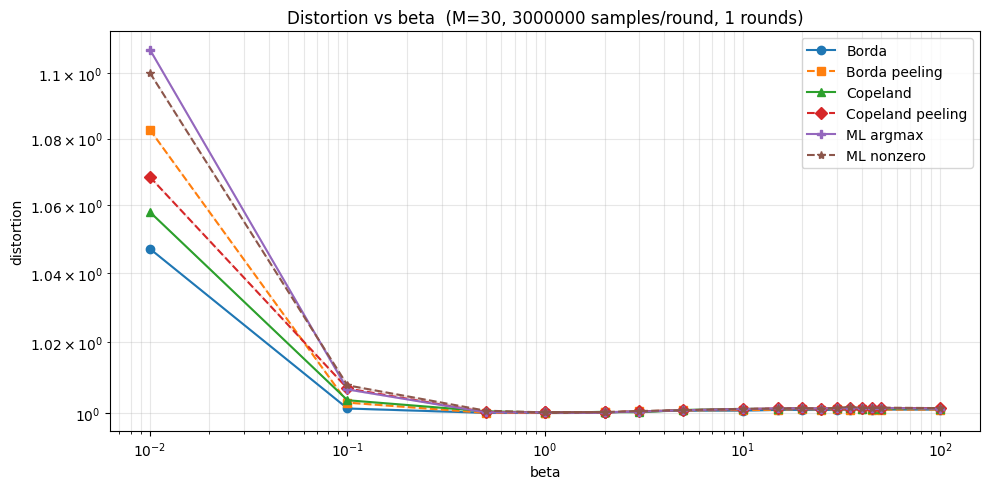

In [196]:
method_style = {
    'borda':            dict(color='C0', marker='o', linestyle='-',  label='Borda'),
    'borda_peeling':    dict(color='C1', marker='s', linestyle='--', label='Borda peeling'),
    'copeland':         dict(color='C2', marker='^', linestyle='-',  label='Copeland'),
    'copeland_peeling': dict(color='C3', marker='D', linestyle='--', label='Copeland peeling'),
    'ml_argmax':        dict(color='C4', marker='P', linestyle='-',  label='ML argmax'),
    'ml_nonzero':       dict(color='C5', marker='*', linestyle='--', label='ML nonzero'),
}

fig, ax = plt.subplots(figsize=(10, 5))
for m, kw in method_style.items():
    means = np.array([np.mean(betas_distortions[m][float(b)]) for b in betas])
    stds  = np.array([np.std( betas_distortions[m][float(b)]) for b in betas])
    ax.plot(betas, means, **kw)
    ax.fill_between(betas, means - stds, means + stds, alpha=0.15, color=kw['color'])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta  (M={pw.M}, {NUM_SAMPLES} samples/round, {NUM_ROUNDS} rounds)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

In [194]:
ij_wins.sum(axis=1) / (ij_wins.sum(axis=0) + ij_wins.sum(axis=1))

array([0.52935768, 0.94239613, 0.76033381, 0.60909664, 0.5893683 ,
       0.83138707, 0.29918394, 0.8380115 , 0.19961886, 0.47779093,
       0.12227887, 0.15383641, 0.28954023, 0.30245465, 0.81184021,
       0.08039425, 0.61293328, 0.55677524, 0.49026981, 0.1025543 ,
       0.84478435, 0.59331066, 0.42488518, 0.76051023, 0.38172217,
       0.48516575, 0.41035815, 0.47470061, 0.1732634 , 0.34356469])